In [37]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from transcription_pipeline import spot_pipeline
from transcription_pipeline.RateExtraction import FitAndAverage
from scipy.stats import linregress
from scipy.ndimage import gaussian_filter1d

In [38]:
dataset_folder = '/mnt/Data1/Nick/transcription_pipeline/'
# dataset_folder = 'mnt/Data1/Hugo/transcription_pipeline/'
key = '002'

embryo_list = {
    '001': [
    'test_data/NSPARC/2025-08-01/MCP-mSG_His-RFP_RBS(001)(homo)_embryo01',
    'test_data/NSPARC/2025-08-01/MCP-mSG_His-RFP_RBS(001)(homo)_embryo02',
	],
	'003': [
	'test_data/NSPARC/2025-07-31/MCP-mSG_His-RFP_RBS(003)(homo)_embryo01',
	'test_data/NSPARC/2025-07-31/MCP-mSG_His-RFP_RBS(003)(homo)_embryo02',
	'test_data/NSPARC/2025-07-31/MCP-mSG_His-RFP_RBS(003)(homo)_embryo03',
	],
    '002': [ # Datasets with 1.5% laser power
        'test_data/NSPARC/2025-08-11/MCP-mSG_His-RFP_RBS(002)(het)_embryo01',
        'test_data/NSPARC/2025-08-11/MCP-mSG_His-RFP_RBS(002)(het)_embryo01_nc13',
        'test_data/NSPARC/2025-08-12/MCP-mSG_His-RFP_RBS(002)(het)_embryo01',
        'test_data/NSPARC/2025-08-12/MCP-mSG_His-RFP_RBS(002)(het)_embryo02',
    ]
}

In [39]:
embryo_id = embryo_list[key][0]
test_dataset_name = os.path.join(dataset_folder, embryo_id)
print(f"Dataset Path: {test_dataset_name}")

# Load spot data
spot_tracking = spot_pipeline.Spot()
spot_tracking.read_results(name_folder=test_dataset_name)
spot_df = spot_tracking.spot_dataframe
detected_spots = spot_df[spot_df["particle"] != 0]

Dataset Path: /mnt/Data1/Nick/transcription_pipeline/test_data/NSPARC/2025-08-11/MCP-mSG_His-RFP_RBS(002)(het)_embryo01


Bootstrap mean integrated intensity: 265.898
Bootstrap std: 19.381062819154167
Number of pixels in spot: 405
128.6201610169492


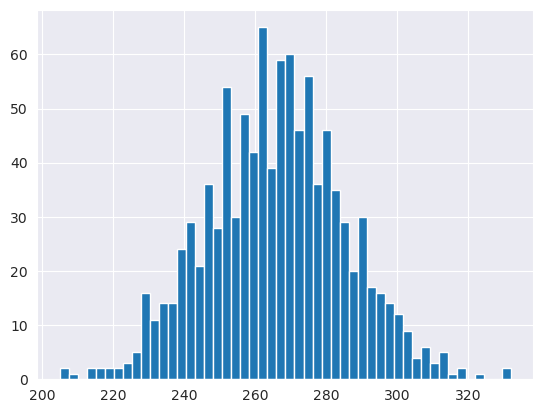

In [40]:
index = 3
pixels = spot_df['raw_spot'].iloc[index].flatten()

# Number of bootstrap replicates
n_bootstrap = 1000

# Store results
integrated_intensities = np.empty(n_bootstrap)

for i in range(n_bootstrap):
    # Bootstrap sample (same number of pixels as original spot)
    sample = np.random.choice(pixels, size=pixels.size, replace=True)

    # Integrated intensity = sum of sampled pixel values
    integrated_intensities[i] = sample.sum()

# Now you can compute statistics
mean_intensity = np.mean(integrated_intensities)
std_intensity = np.std(integrated_intensities)

print(f"Bootstrap mean integrated intensity: {mean_intensity}")
print(f"Bootstrap std: {std_intensity}")
print(f"Number of pixels in spot: {pixels.size}")

plt.hist(integrated_intensities, bins=50);

intensity_bkgSub = mean_intensity - (pixels.size)*spot_df['background_intensity_from_neighborhood'].iloc[index]

print(intensity_bkgSub)


In [41]:
spot_df.head()

,label,z,y,x,frame,t_s,t_frame,raw_spot,coordinates_start,covariance_matrix,...,offset,cost,norm_cost,intensity_from_fit,intensity_std_error_from_fit,intensity_from_neighborhood,intensity_std_error_from_neighborhood,background_intensity_from_neighborhood,background_intensity_std_error_from_neighborhood,particle
0,2,12.479717,202.536381,103.341415,0,4.700753,2,"[[[0, 1, 1, 0, 0, 0, 1, 1, 1], [1, 1, 0, 0, 0,...","[0, 10, 198, 98]","[[0.006446577275148215, -1.0174503050855167e-0...",...,0.388055,76.916895,0.005091,64.844228,5.868435,88.269000,16.282403,0.331333,0.054797,121
1,3,13.612875,88.984385,21.070821,0,4.874720,2,"[[[1, 0, 0, 0, 0, 1, 0, 0, 0], [0, 1, 0, 0, 0,...","[0, 11, 84, 16]","[[0.005409690843044612, 2.639085317084571e-08,...",...,0.380863,66.850792,0.004522,73.504605,6.051991,80.401314,13.713832,0.363793,0.048097,152
2,1,9.142848,171.733732,264.665762,2,7.854670,3,"[[[1, 0, 1, 1, 0, 1, 2, 1, 0], [2, 0, 1, 1, 1,...","[2, 6, 167, 260]","[[0.003941195922678961, -1.912350748899692e-07...",...,0.391455,86.397577,0.005397,61.794421,6.246913,42.459000,15.123118,0.417000,0.046893,134
3,3,13.435940,89.189808,21.472472,2,8.920725,4,"[[[0, 0, 1, 0, 1, 1, 1, 0, 0], [0, 0, 1, 0, 0,...","[2, 11, 84, 17]","[[0.006399821191242485, 4.629894388999493e-08,...",...,0.409800,78.596089,0.005119,106.691414,8.331680,124.190831,15.723524,0.338958,0.048499,152
4,1,9.619317,171.723077,263.498897,3,9.877672,4,"[[[0, 0, 0, 0, 0, 0, 0, 0, 0], [2, 0, 0, 0, 0,...","[3, 6, 167, 259]","[[0.02582568801664897, -4.4165184756765503e-07...",...,0.424621,115.742034,0.006148,111.969131,13.336089,66.037149,18.505718,0.528336,0.065964,134


array([[<Axes: title={'center': 'spearman_S_B'}>,
        <Axes: title={'center': 'pearson_S_B'}>],
       [<Axes: title={'center': 'spearman_diff'}>,
        <Axes: title={'center': 'pearson_diff'}>]], dtype=object)

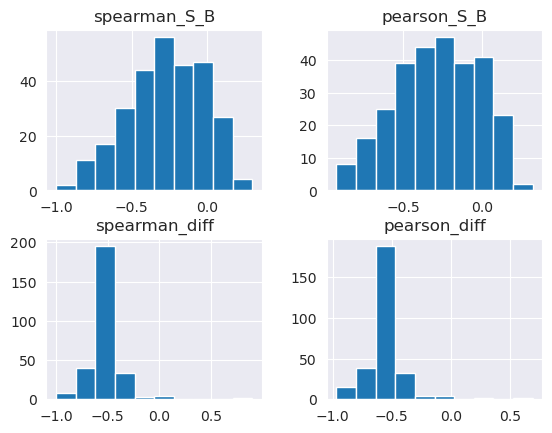

In [42]:
import numpy as np
import pandas as pd
from scipy.stats import spearmanr, pearsonr
from numpy.linalg import lstsq

def _normalized_xcorr(x, y, max_lag=5):
    x = (x - np.mean(x)) / (np.std(x) + 1e-12)
    y = (y - np.mean(y)) / (np.std(y) + 1e-12)
    lags = np.arange(-max_lag, max_lag+1)
    vals = []
    for tau in lags:
        if tau < 0:
            xs, ys = x[:tau], y[-tau:]
        elif tau > 0:
            xs, ys = x[tau:], y[:-tau]
        else:
            xs, ys = x, y
        if len(xs) < 3:
            vals.append(np.nan)
        else:
            vals.append(np.mean(xs*ys))
    return lags, np.array(vals, float)

def _ols_alpha(S, B, t):
    # B ~ beta0 + alpha*S + poly(t,2)
    X = np.column_stack([np.ones_like(S), S, t, t**2])
    coef, *_ = lstsq(X, B, rcond=None)
    return coef[1]  # alpha

def compute_bg_contamination_metrics(df,
                                     spot_col='spot_id',
                                     frame_col='frame',
                                     signal_col='signal',
                                     bg_col='local_bg',
                                     max_lag=5):
    out = []
    for spot, g in df.groupby(spot_col):
        g = g.sort_values(frame_col)
        S = g[signal_col].to_numpy(dtype=float)
        B = g[bg_col].to_numpy(dtype=float)
        if len(S) < 6:
            continue

        # (1) Zero-lag correlations
        spear = spearmanr(S, B, nan_policy='omit')[0]
        pear = pearsonr(S, B)[0] if np.std(S)>0 and np.std(B)>0 else np.nan

        # (2) Cross-correlation shape
        lags, xcorr = _normalized_xcorr(S, B, max_lag=max_lag)
        zero_idx = np.where(lags==0)[0][0]
        xcorr_zero = xcorr[zero_idx]
        xcorr_peak = np.nanmax(xcorr)
        lag_at_peak = lags[np.nanargmax(xcorr)]

        # (3) Leakage coefficient alpha (with simple detrend)
        t = np.arange(len(S), dtype=float)
        alpha = _ols_alpha(S, B, (t - t.mean())/t.std())

        # (4) Co-fluctuation of first differences
        dS = np.diff(S)
        dB = np.diff(B)
        spear_diff = spearmanr(dS, dB, nan_policy='omit')[0] if len(dS)>=3 else np.nan
        pear_diff = pearsonr(dS, dB)[0] if len(dS)>=3 and np.std(dS)>0 and np.std(dB)>0 else np.nan

        out.append({
            spot_col: spot,
            'spearman_S_B': spear,
            'pearson_S_B': pear,
            'xcorr_zero': xcorr_zero,
            'xcorr_peak': xcorr_peak,
            'lag_at_peak': lag_at_peak,
            'alpha_leak': alpha,
            'spearman_diff': spear_diff,
            'pearson_diff': pear_diff,
            'n_frames': len(S),
        })
    return pd.DataFrame(out)

# ---- Example usage ----
metrics = compute_bg_contamination_metrics(detected_spots, spot_col='particle',
                                           frame_col='t_frame',
                                           signal_col='intensity_from_neighborhood',
                                           bg_col='background_intensity_from_neighborhood',)
# Now inspect:
metrics.sort_values('alpha_leak', ascending=False).head()
metrics.hist(column=['spearman_S_B', 'pearson_S_B', 'spearman_diff', 'pearson_diff'], bins=10)
